<a href="https://colab.research.google.com/github/vc-alejandro/model_implement/blob/main/telco_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediccion de Churn - Telco Customer Churn



## 0. Conexion con GitHub

Para reutilzar Decision Tree

In [1]:
import os
import urllib.request

REPO_RAW = "https://raw.githubusercontent.com/vc-alejandro/model_implement/main"

archivos_necesarios = ["decision_tree.py", "WA_Fn-UseC_-Telco-Customer-Churn.csv"]

for nombre_archivo in archivos_necesarios:
    if not os.path.exists(nombre_archivo):
        url = f"{REPO_RAW}/{nombre_archivo}"
        urllib.request.urlretrieve(url, nombre_archivo)
        print(f"Descargado {nombre_archivo} desde GitHub")
    else:
        print(f"{nombre_archivo} ya disponible localmente")

Descargado decision_tree.py desde GitHub
Descargado WA_Fn-UseC_-Telco-Customer-Churn.csv desde GitHub


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from decision_tree import DecisionTree

pd.set_option('display.max_columns', None)

## 1. Carga de datos

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Limpieza


In [5]:
blancos = df['TotalCharges'].str.strip() == ''
print('Filas con TotalCharges en blanco:', blancos.sum())
df.loc[blancos, ['customerID', 'tenure', 'TotalCharges']]

Filas con TotalCharges en blanco: 11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


In [6]:
df['TotalCharges'] = df['TotalCharges'].str.strip().replace('', '0')
df['TotalCharges'] = df['TotalCharges'].astype(float)

# customerID no es una feature, es solo un identificador
df = df.drop(columns=['customerID'])

## 3. Analisis exploratorio (EDA)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporcion:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


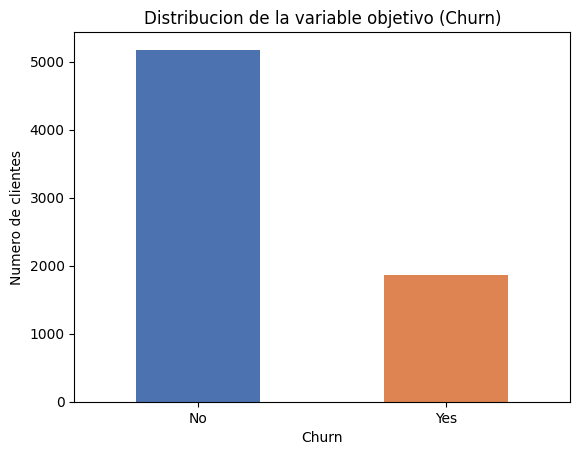

In [7]:
conteo_churn = df['Churn'].value_counts()
print(conteo_churn)
print('\nProporcion:')
print(df['Churn'].value_counts(normalize=True).round(3))

conteo_churn.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Distribucion de la variable objetivo (Churn)')
plt.ylabel('Numero de clientes')
plt.xticks(rotation=0)
plt.show()

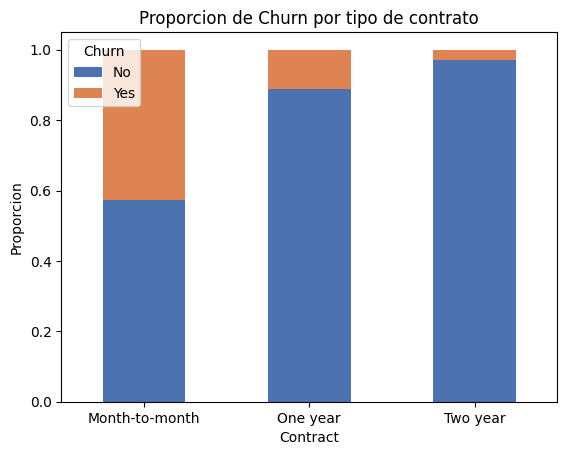

In [8]:
# Churn por tipo de contrato
tabla = pd.crosstab(df['Contract'], df['Churn'], normalize='index')
tabla.plot(kind='bar', stacked=True, color=['#4C72B0', '#DD8452'])
plt.title('Proporcion de Churn por tipo de contrato')
plt.ylabel('Proporcion')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

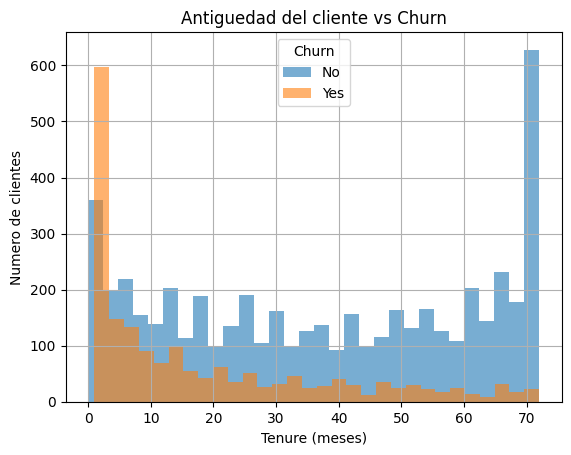

In [9]:
# Distribucion de tenure (antiguedad) separada por Churn
fig, ax = plt.subplots()
df[df['Churn']=='No']['tenure'].hist(alpha=0.6, bins=30, label='No', ax=ax)
df[df['Churn']=='Yes']['tenure'].hist(alpha=0.6, bins=30, label='Yes', ax=ax)
ax.set_xlabel('Tenure (meses)')
ax.set_ylabel('Numero de clientes')
ax.set_title('Antiguedad del cliente vs Churn')
ax.legend(title='Churn')
plt.show()

## 4. Separacion train / test

80% entrenamiento / 20% prueba, estratificado por la variable `Churn`
para conservar la misma proporcion de clases en ambos conjuntos.

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# reset_index para que el arbol manual pueda indexar filas 0..n-1
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (5634, 19)  Test: (1409, 19)


## 5. Entrenamiento del arbol manual (`decision_tree.py`)

`max_depth` y `min_samples_split` se eligieron para evitar overfitting

In [11]:
arbol = DecisionTree(max_depth=5, min_samples_split=20)
arbol.fit(X_train, y_train)
print('Arbol entrenado.')

Arbol entrenado.


In [12]:
arbol.imprimir_arbol()

[Contract == Month-to-month]  (ganancia=0.1336)
 Si:
   [InternetService == Fiber optic]  (ganancia=0.0559)
    Si:
      [tenure <= 13.50]  (ganancia=0.0609)
       Si:
         [TotalCharges <= 120.00]  (ganancia=0.0274)
          Si:
            [MonthlyCharges <= 69.93]  (ganancia=0.0428)
             Si:
               -> Prediccion: Yes
             No:
               -> Prediccion: Yes
          No:
            [MonthlyCharges <= 78.20]  (ganancia=0.0277)
             Si:
               -> Prediccion: Yes
             No:
               -> Prediccion: Yes
       No:
         [PaymentMethod == Electronic check]  (ganancia=0.0185)
          Si:
            [TotalCharges <= 3078.40]  (ganancia=0.0187)
             Si:
               -> Prediccion: Yes
             No:
               -> Prediccion: No
          No:
            [tenure <= 51.50]  (ganancia=0.0195)
             Si:
               -> Prediccion: No
             No:
               -> Prediccion: No
    No:
      [tenure

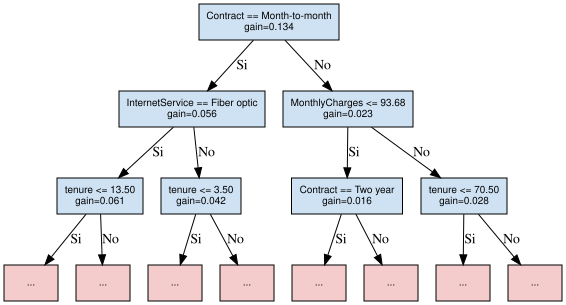

In [19]:
import graphviz

def graficar_arbol(nodo, grafo=None, id_nodo="0", profundidad_max=3, profundidad_actual=0):
    if grafo is None:
        grafo = graphviz.Digraph()
        grafo.attr("node", shape="box", fontname="Helvetica", fontsize="10")

    if nodo["hoja"]:
        grafo.node(id_nodo, f"Prediccion:\n{nodo['prediccion']}",
                   style="filled", fillcolor="#D9EAD3")
        return grafo

    if profundidad_actual >= profundidad_max:
        grafo.node(id_nodo, "...", style="filled", fillcolor="#F4CCCC")
        return grafo

    if nodo["tipo"] == "numerico":
        etiqueta = f"{nodo['columna']} <= {nodo['valor']:.2f}"
    else:
        etiqueta = f"{nodo['columna']} == {nodo['valor']}"
    etiqueta += f"\ngain={nodo['ganancia']:.3f}"

    grafo.node(id_nodo, etiqueta, style="filled", fillcolor="#CFE2F3")

    id_izq = id_nodo + "0"
    id_der = id_nodo + "1"
    graficar_arbol(nodo["izquierda"], grafo, id_izq, profundidad_max, profundidad_actual + 1)
    graficar_arbol(nodo["derecha"], grafo, id_der, profundidad_max, profundidad_actual + 1)

    grafo.edge(id_nodo, id_izq, label="Si")
    grafo.edge(id_nodo, id_der, label="No")

    return grafo


grafo = graficar_arbol(arbol.raiz, profundidad_max=3)
grafo

## 6. Predicciones y matriz de confusion (arbol manual)

In [13]:
predicciones = arbol.predict(X_test)
y_test_list = y_test.tolist()

In [14]:
def matriz_confusion(y_real, y_pred, clase_positiva='Yes'):
    vp = sum(1 for r, p in zip(y_real, y_pred) if r == clase_positiva and p == clase_positiva)
    vn = sum(1 for r, p in zip(y_real, y_pred) if r != clase_positiva and p != clase_positiva)
    fp = sum(1 for r, p in zip(y_real, y_pred) if r != clase_positiva and p == clase_positiva)
    fn = sum(1 for r, p in zip(y_real, y_pred) if r == clase_positiva and p != clase_positiva)
    return vp, vn, fp, fn


def metricas(vp, vn, fp, fn):
    accuracy = (vp + vn) / (vp + vn + fp + fn)
    precision = vp / (vp + fp) if (vp + fp) > 0 else 0.0
    recall = vp / (vp + fn) if (vp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

In [15]:
vp, vn, fp, fn = matriz_confusion(y_test_list, predicciones)
print(f'Verdaderos Positivos (Churn=Yes correcto): {vp}')
print(f'Verdaderos Negativos (Churn=No correcto):  {vn}')
print(f'Falsos Positivos (predijo Yes, era No):    {fp}')
print(f'Falsos Negativos (predijo No, era Yes):    {fn}')

res_manual = metricas(vp, vn, fp, fn)
for k, v in res_manual.items():
    print(f'{k}: {v:.3f}')

Verdaderos Positivos (Churn=Yes correcto): 212
Verdaderos Negativos (Churn=No correcto):  912
Falsos Positivos (predijo Yes, era No):    123
Falsos Negativos (predijo No, era Yes):    162
accuracy: 0.798
precision: 0.633
recall: 0.567
f1: 0.598


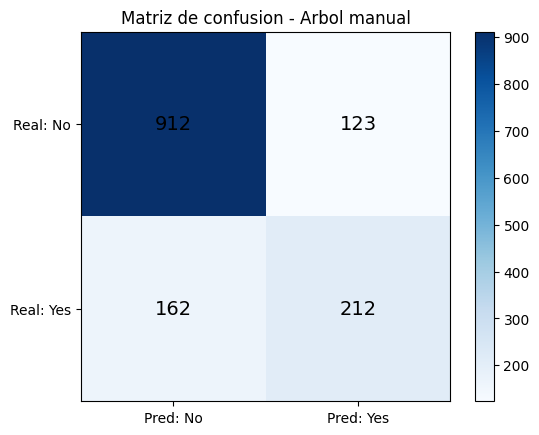

In [16]:
# Visualizacion de la matriz de confusion
matriz = np.array([[vn, fp], [fn, vp]])
fig, ax = plt.subplots()
im = ax.imshow(matriz, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred: No', 'Pred: Yes'])
ax.set_yticklabels(['Real: No', 'Real: Yes'])
ax.set_title('Matriz de confusion - Arbol manual')

for i in range(2):
    for j in range(2):
        ax.text(j, i, matriz[i, j], ha='center', va='center', color='black', fontsize=14)

plt.colorbar(im)
plt.show()

## 7. Comparacion contra scikit-learn

Mismo criterio (`entropy`), misma profundidad maxima y mismo
`min_samples_split`, para que la comparacion sea justa. La unica
diferencia real es que sklearn requiere las categoricas codificadas
como numeros (`LabelEncoder`), mientras que el arbol manual las
compara directamente como texto.

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()
columnas_categoricas = X_encoded.select_dtypes(include=['object']).columns

for col in columnas_categoricas:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

modelo_sklearn = DecisionTreeClassifier(
    criterion='entropy', max_depth=5, min_samples_split=20, random_state=42
)
modelo_sklearn.fit(Xe_train, ye_train)
pred_sklearn = modelo_sklearn.predict(Xe_test)

In [18]:
vp2, vn2, fp2, fn2 = matriz_confusion(ye_test.tolist(), pred_sklearn.tolist())
res_sklearn = metricas(vp2, vn2, fp2, fn2)

comparacion = pd.DataFrame({
    'Arbol manual': res_manual,
    'sklearn (entropy)': res_sklearn,
})
comparacion

,Arbol manual,sklearn (entropy)
accuracy,0.797729,0.784244
precision,0.632836,0.601744
recall,0.566845,0.553476
f1,0.598025,0.576602
